# NumPy 3 — statistics, linear algebra, random numbers

**What's in here**
- `mean/std/var` and the `ddof` difference between numpy and pandas
- NaN-aware reductions, percentiles, correlation and covariance
- `np.polyfit` for a quick trend
- OLS three ways: normal equations, `lstsq`, sklearn — and why they agree
- `inv`, `solve`, `norm`, `@` vs `*`
- Reproducible random numbers, a small Monte Carlo (AR(1) simulation)
- numpy vs pandas: positional vs index-aligned

In [1]:
import numpy as np
import pandas as pd

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.width", 120)
print(np.__version__, pd.__version__)

df = pd.read_csv("../data/hourly_power_clean.csv", parse_dates=["time"])
cons = df["consumption_mwh"].to_numpy()
temp = df["temp_c"].to_numpy()
price = df["price_eur_mwh"].to_numpy()
wind = df["wind_ms"].to_numpy()
print(df.shape)

1.26.4 2.3.3
(17520, 6)


## Mean, std, var — and `ddof`
`np.std` defaults to `ddof=0` (population, divide by n). `pd.Series.std` defaults to `ddof=1` (sample, divide by n-1). They differ, and for small samples the difference is material. Pick one deliberately and be consistent.

**Interview check:** "Your volatility number doesn't match mine" → check `ddof`.

In [2]:
x = np.array([2.0, 4.0, 4.0, 4.0, 5.0, 5.0, 7.0, 9.0])
print("numpy  std (ddof=0):", x.std())
print("numpy  std (ddof=1):", x.std(ddof=1))
print("pandas std (default ddof=1):", pd.Series(x).std())
print("pandas std (ddof=0):", pd.Series(x).std(ddof=0))
print("ratio for n=8:", np.sqrt(8 / 7).round(4))

print("consumption mean/std:", cons.mean().round(1), cons.std().round(1), " var:", cons.var().round(0))

numpy  std (ddof=0): 2.0
numpy  std (ddof=1): 2.138089935299395
pandas std (default ddof=1): 2.138089935299395
pandas std (ddof=0): 2.0
ratio for n=8: 1.069
consumption mean/std: 29315.3 4204.8  var: 17680502.0


## NaN-aware reductions
A single NaN poisons `mean`, `sum`, `max`. `np.nanmean`, `np.nansum`, `np.nanmax`, `np.nanstd` ignore NaN. `np.nansum` of all-NaN is 0 (not NaN) — be aware. pandas reductions skip NaN by default (`skipna=True`).

In [3]:
t = temp.copy()
t[::100] = np.nan
print("mean with NaN:", t.mean(), " nanmean:", np.nanmean(t).round(3), " count non-nan:", np.count_nonzero(~np.isnan(t)))
print("nansum of all-NaN:", np.nansum([np.nan, np.nan]), "  nanmean of all-NaN:", end=" ")
with np.errstate(all="ignore"):
    print(np.nanmean([np.nan, np.nan]))
print("pandas skips NaN by default:", pd.Series(t).mean().round(3))

mean with NaN: nan  nanmean: 9.933  count non-nan: 17344
nansum of all-NaN: 0.0   nanmean of all-NaN: nan
pandas skips NaN by default: 9.933


/tmp/ipykernel_100343/1150614571.py:6: RuntimeWarning: Mean of empty slice
  print(np.nanmean([np.nan, np.nan]))


## Percentiles and quantiles
`np.percentile(x, 95)` and `np.quantile(x, 0.95)` are the same thing on different scales. Pass a list to get several at once. Useful for robust summaries and for spotting outliers/fat tails (compare the 99th percentile with the max).

In [4]:
print("price percentiles 1/5/50/95/99:", np.percentile(price, [1, 5, 50, 95, 99]).round(1))
print("price max:", price.max(), " -> the max is far beyond p99: spikes")
print("IQR of consumption:", np.subtract(*np.percentile(cons, [75, 25])).round(0))
print("nan-safe:", np.nanpercentile(np.array([1, 2, np.nan, 4]), 50))

price percentiles 1/5/50/95/99: [ 17.9  40.4  97.7 157.8 183.7]
price max: 419.6  -> the max is far beyond p99: spikes
IQR of consumption: 5923.0
nan-safe: 2.0


## Correlation and covariance
`np.corrcoef(a, b)` returns the 2×2 correlation matrix — take `[0, 1]`. Pass a matrix with `rowvar=False` to get a correlation matrix across columns (pandas `df.corr()` does the same with labels). `np.cov` likewise, with `ddof=1` by default (unlike `np.var`!).

In [5]:
print("corr(temp, cons):", np.corrcoef(temp, cons)[0, 1].round(3))

X = np.column_stack([cons, temp, wind, price])
names = ["cons", "temp", "wind", "price"]
C = np.corrcoef(X, rowvar=False)
print(pd.DataFrame(C, index=names, columns=names).round(2))

print("np.cov ddof default is 1:", np.isclose(np.cov(temp), temp.var(ddof=1)))

corr(temp, cons): -0.221
       cons  temp  wind  price
cons   1.00 -0.22  0.03   0.58
temp  -0.22  1.00 -0.05  -0.14
wind   0.03 -0.05  1.00  -0.31
price  0.58 -0.14 -0.31   1.00
np.cov ddof default is 1: True


## `np.polyfit` — quick trend line
Least-squares polynomial fit. Degree 1 gives slope and intercept — quick way to estimate a trend or a sensitivity (here: MWh per °C). `np.polyval` evaluates it. For anything serious move to proper OLS below.

In [6]:
slope, intercept = np.polyfit(temp, cons, deg=1)
print(f"consumption ≈ {intercept:,.0f} + {slope:,.0f} * temp   (MWh per °C)")

coefs2 = np.polyfit(temp, cons, deg=2)          # highest power first
print("quadratic coefs:", coefs2.round(2))
fitted = np.polyval(coefs2, temp)
print("R² of quadratic:", (1 - ((cons - fitted) ** 2).sum() / ((cons - cons.mean()) ** 2).sum()).round(3))

# time trend: MWh per hour of elapsed time
t_idx = np.arange(len(cons))
print("trend per hour:", np.polyfit(t_idx, cons, 1)[0].round(4), " -> per year:", (np.polyfit(t_idx, cons, 1)[0] * 8760).round(0))

consumption ≈ 30,694 + -139 * temp   (MWh per °C)
quadratic coefs: [    8.08  -299.3  31128.8 ]
R² of quadratic: 0.057
trend per hour: -0.0717  -> per year: -628.0


## Matrix vs elementwise multiplication
`*` is elementwise (with broadcasting). `@` (or `np.dot`) is matrix multiplication. Mixing them up produces either an error or, worse, a wrong answer with a plausible shape.

In [7]:
A = np.array([[1, 2], [3, 4]])
B = np.array([[10, 20], [30, 40]])
print("A * B (elementwise):\n", A * B)
print("A @ B (matrix):\n", A @ B)
v = np.array([1, 1])
print("A @ v:", A @ v, "  v @ v (dot product):", v @ v, "  np.outer:\n", np.outer(v, [1, 2]))

A * B (elementwise):
 [[ 10  40]
 [ 90 160]]
A @ B (matrix):
 [[ 70 100]
 [150 220]]
A @ v: [3 7]   v @ v (dot product): 2   np.outer:
 [[1 2]
 [1 2]]


## OLS three ways
Model: `y = X β + ε`. With an intercept column of ones in `X`:

1. **Normal equations**: `β = (XᵀX)⁻¹ Xᵀ y` — the textbook formula. Uses `inv`, numerically the worst choice.
2. **`np.linalg.solve(XᵀX, Xᵀy)`** — same equations, but solves the system without forming the inverse. Better.
3. **`np.linalg.lstsq(X, y)`** — a least-squares solver (SVD-based) that also handles rank deficiency. Best default.

Then compare with sklearn's `LinearRegression`, which uses lstsq under the hood and adds the intercept for you.

In [8]:
hour = df["time"].dt.hour.to_numpy()
hdd = np.maximum(15 - temp, 0)                  # heating degree
X = np.column_stack([np.ones(len(df)), temp, hdd, wind, hour])
y = cons
feat = ["const", "temp", "hdd", "wind", "hour"]
print(X.shape, y.shape)

beta_inv = np.linalg.inv(X.T @ X) @ X.T @ y
beta_solve = np.linalg.solve(X.T @ X, X.T @ y)
beta_lstsq, resid_ss, rank, sv = np.linalg.lstsq(X, y, rcond=None)

print(pd.DataFrame({"inv": beta_inv, "solve": beta_solve, "lstsq": beta_lstsq}, index=feat).round(2))
print("rank:", rank, " of", X.shape[1])

(17520, 5) (17520,)
            inv     solve     lstsq
const  19921.46  19921.46  19921.46
temp     205.05    205.05    205.05
hdd      516.21    516.21    516.21
wind      39.74     39.74     39.74
hour     347.67    347.67    347.67
rank: 5  of 5


In [9]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression().fit(X[:, 1:], y)       # sklearn adds its own intercept -> drop the ones column
print("sklearn intercept:", lr.intercept_.round(2))
print("sklearn coefs:    ", lr.coef_.round(2))
print("match lstsq?", np.allclose(np.r_[lr.intercept_, lr.coef_], beta_lstsq))

sklearn intercept: 19921.46
sklearn coefs:     [205.05 516.21  39.74 347.67]
match lstsq? True


**Pitfall:** if you keep the column of ones *and* let sklearn fit an intercept, `X` is rank-deficient (the constant appears twice). lstsq still returns *an* answer (minimum-norm), sklearn still runs, but the two intercept-like coefficients are individually meaningless. Perfect collinearity also shows up as a warning from `inv` or as `rank < n_features`.

In [10]:
X_dup = np.column_stack([X, X[:, 1] * 2])       # add a column that is exactly 2*temp
b, _, rank_dup, sv_dup = np.linalg.lstsq(X_dup, y, rcond=None)
print("rank:", rank_dup, "of", X_dup.shape[1], "  smallest singular value:", sv_dup.min())
print("temp and 2*temp coefs (arbitrary split):", b[1].round(3), b[-1].round(3), " combined effect:", (b[1] + 2 * b[-1]).round(3))
print("original temp coef:", beta_lstsq[1].round(3))

rank: 5 of 6   smallest singular value: 3.726431780078413e-14
temp and 2*temp coefs (arbitrary split): 41.01 82.021  combined effect: 205.052
original temp coef: 205.052


Residuals, R² and coefficient standard errors by hand — this is what `statsmodels` would print, and it's good to know where the numbers come from.

In [11]:
y_hat = X @ beta_lstsq
resid = y - y_hat
n, k = X.shape
ss_res = resid @ resid
ss_tot = ((y - y.mean()) ** 2).sum()
r2 = 1 - ss_res / ss_tot
sigma2 = ss_res / (n - k)
se = np.sqrt(np.diag(sigma2 * np.linalg.inv(X.T @ X)))
print(pd.DataFrame({"coef": beta_lstsq, "se": se, "t": beta_lstsq / se}, index=feat).round(3))
print("R²:", r2.round(4), " RMSE:", np.sqrt(ss_res / n).round(1))

            coef       se       t
const  19921.463  265.613  75.002
temp     205.052   14.859  13.800
hdd      516.210   17.875  28.879
wind      39.735    9.843   4.037
hour     347.674    3.623  95.960
R²: 0.4027  RMSE: 3249.7


## `inv`, `solve`, `norm`, `det`
Prefer `solve(A, b)` over `inv(A) @ b`: faster and more accurate. `norm` gives vector/matrix norms (default: Euclidean / Frobenius). `np.linalg.cond` flags ill-conditioned matrices — large means the inverse is unstable.

In [12]:
A = np.array([[4.0, 1.0], [2.0, 3.0]])
b = np.array([1.0, 2.0])
print("solve:", np.linalg.solve(A, b), " inv@b:", np.linalg.inv(A) @ b)
print("det:", np.linalg.det(A).round(3), " cond:", np.linalg.cond(A).round(3))
print("norm of residuals:", np.linalg.norm(resid).round(1), " == sqrt(ss_res):", np.sqrt(ss_res).round(1))
print("cond of X'X:", f"{np.linalg.cond(X.T @ X):.3g}", "  (large: scale your features)")

solve: [0.1 0.6]  inv@b: [0.1 0.6]
det: 10.0  cond: 2.618
norm of residuals: 430139.1  == sqrt(ss_res): 430139.1
cond of X'X: 4.14e+04   (large: scale your features)


## Reproducible random numbers
Create one `rng = np.random.default_rng(seed)` at the top and pass it around. Every draw advances its state, so the *order* of calls matters for reproducibility.

In [13]:
rng = np.random.default_rng(0)
print("normal:     ", rng.normal(0, 1, 3))
print("uniform:    ", rng.uniform(-1, 1, 3))
print("integers:   ", rng.integers(1, 7, 5))                  # dice, high exclusive
print("choice:     ", rng.choice(["a", "b", "c"], 5, p=[.6, .3, .1]))
print("permutation:", rng.permutation(5))
print("shuffle rows of a matrix:", rng.permutation(np.arange(12).reshape(4, 3), axis=0)[0])
print("sample without replacement:", rng.choice(np.arange(100), 5, replace=False))

normal:      [ 0.1257 -0.1321  0.6404]
uniform:     [-0.9669  0.6265  0.8255]
integers:    [4 4 6 5 4]
choice:      ['c' 'b' 'a' 'b' 'a']
permutation: [0 4 2 3 1]
shuffle rows of a matrix: [3 4 5]
sample without replacement: [ 7 42 47 51 29]


Bootstrap in two lines: resample indices with replacement, recompute the statistic. Here: a confidence interval for the temp coefficient of a simple regression.

In [14]:
rng = np.random.default_rng(1)
n = len(cons)
slopes = np.empty(500)
for i in range(500):
    idx = rng.integers(0, n, n)                 # resample with replacement
    slopes[i] = np.polyfit(temp[idx], cons[idx], 1)[0]
print("slope point estimate:", np.polyfit(temp, cons, 1)[0].round(1))
print("bootstrap 95% CI:", np.percentile(slopes, [2.5, 97.5]).round(1))

slope point estimate: -138.8
bootstrap 95% CI: [-146.7 -131.1]


## Monte Carlo: simulate an AR(1) process
`x_t = φ x_{t-1} + ε_t`. The recursion is sequential so the inner loop stays a loop, but we simulate all paths at once (vectorised across paths). Check the simulated moments against theory: variance = σ²/(1-φ²).

**Interview check:** "Why is the variance across paths different from the variance along one path?" → stationarity/ergodicity; also burn-in — start from the stationary distribution or discard the start.

In [15]:
rng = np.random.default_rng(123)
phi, sigma, T, n_paths = 0.9, 1.0, 2000, 500

eps = rng.normal(0, sigma, size=(T, n_paths))
x = np.zeros((T, n_paths))
x[0] = rng.normal(0, sigma / np.sqrt(1 - phi**2), n_paths)   # start in stationary distribution
for t in range(1, T):
    x[t] = phi * x[t - 1] + eps[t]

print("theoretical var:", round(sigma**2 / (1 - phi**2), 3))
print("simulated var (all):", x.var().round(3))
print("lag-1 autocorr (path 0):", np.corrcoef(x[1:, 0], x[:-1, 0])[0, 1].round(3), " theory:", phi)
print("fitted phi via polyfit on path 0:", np.polyfit(x[:-1, 0], x[1:, 0], 1)[0].round(3))

theoretical var: 5.263
simulated var (all): 5.253
lag-1 autocorr (path 0): 0.908  theory: 0.9
fitted phi via polyfit on path 0: 0.908


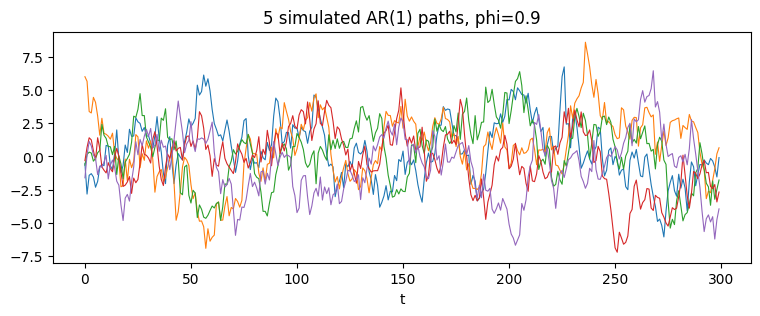

In [16]:
%matplotlib inline
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(x[:300, :5], lw=0.8)
ax.set_title("5 simulated AR(1) paths, phi=0.9"); ax.set_xlabel("t")
plt.show()

## numpy vs pandas: positional vs aligned
numpy is **positional**: element i of `a` meets element i of `b`. pandas is **index-aligned**: Series arithmetic matches on the index labels, filling NaN where labels don't match. This is the source of the classic "I subtracted two Series and got all NaN" bug — and also why you must be careful when mixing `.values` with Series.

`.to_numpy()` (preferred) and `.values` both drop the index and give you the raw array.

In [17]:
s1 = pd.Series([1.0, 2.0, 3.0], index=[0, 1, 2])
s2 = pd.Series([10.0, 20.0, 30.0], index=[1, 2, 3])
print("pandas aligned:\n", s1 - s2)                          # NaN at 0 and 3
print("numpy positional:", s1.to_numpy() - s2.to_numpy())

# after filtering, indexes differ -> aligned ops can produce mostly NaN
a = df["consumption_mwh"][df["temp_c"] < 5]
b = df["consumption_mwh"][df["temp_c"] > 15]
print("aligned diff, non-null count:", (a - b).notna().sum(), " of", len(a))

pandas aligned:
 0     NaN
1    -8.0
2   -17.0
3     NaN
dtype: float64
numpy positional: [ -9. -18. -27.]
aligned diff, non-null count: 0  of 4806


**Pitfall:** assigning a numpy array back into a *filtered* DataFrame works positionally — the array must be exactly the length of the filtered frame, and pandas will not check that the rows correspond to what you think. Also, `to_numpy()` on a mixed-dtype frame gives an `object` array, which is slow and breaks numeric functions.

In [18]:
sub = df[df["temp_c"] < 0].copy()
sub["hdd"] = np.maximum(15 - sub["temp_c"].to_numpy(), 0)    # positional, same length: fine
print(sub[["temp_c", "hdd"]].head(3))

print("numeric frame ->", df[["temp_c", "wind_ms"]].to_numpy().dtype)
print("mixed frame   ->", df[["time", "temp_c"]].to_numpy().dtype)

   temp_c    hdd
1   -0.18  15.18
2   -1.11  16.11
3   -0.75  15.75
numeric frame -> float64
mixed frame   -> object


## Quick reference

| Task | Code |
|---|---|
| sample std | `x.std(ddof=1)` (pandas default) |
| ignore NaN | `np.nanmean(x)`, `np.nanstd(x)` |
| percentiles | `np.percentile(x, [5, 50, 95])` |
| correlation | `np.corrcoef(a, b)[0, 1]` |
| corr matrix by column | `np.corrcoef(X, rowvar=False)` |
| trend line | `slope, icpt = np.polyfit(t, y, 1)` |
| OLS | `beta, *_ = np.linalg.lstsq(X, y, rcond=None)` |
| linear system | `np.linalg.solve(A, b)` |
| matrix multiply | `A @ B` |
| seeded rng | `rng = np.random.default_rng(42)` |
| bootstrap indices | `rng.integers(0, n, n)` |
| Series → array | `s.to_numpy()` |